# Behavioral Analysis for Wolbachia Experiment

## Imports and functions

In [37]:
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import unityvr.preproc.logproc as lp

from gulp2p.preproc import utils
from gulp2p.viz import plotting 


## Select data files

In [38]:
# Select unity vr file from the dark trial segment
dark_stim_path = utils.select_file_path(prompt="Select dark stim file")

In [39]:
# Select unity vr file from the grating trial segment
grating_stim_path = utils.select_file_path(prompt="Select grating stim file", initialdir=dark_stim_path.parent)

In [40]:
# Select unity vr file from the closed loop trial segment
closed_loop_stim_path = utils.select_file_path(prompt="Select closed loop stim file", initialdir=grating_stim_path.parent)

In [41]:
print("Data Files Chosen:")
print(f"Dark stimuli file: {dark_stim_path}")
print(f"Grating stimuli file: {grating_stim_path}")
print(f"Closed loop stimuli file: {closed_loop_stim_path}")

Data Files Chosen:
Dark stimuli file: Z:\FlyVR\FlyVR data\Edwin\2023-07-24\4+\Log_2023-07-24_12-13-21.json
Grating stimuli file: Z:\FlyVR\FlyVR data\Edwin\2023-07-24\4+\Log_2023-07-24_12-19-33.json
Closed loop stimuli file: Z:\FlyVR\FlyVR data\Edwin\2023-07-24\4+\Log_2023-07-24_12-26-34.json


## Parse Data

In [42]:
uvr_dict = {
    'dark_stim': lp.constructUnityVRexperiment(str(dark_stim_path.parent), dark_stim_path.name),
    'grating_stim': lp.constructUnityVRexperiment(str(grating_stim_path.parent), grating_stim_path.name),
    'closed_loop_stim': lp.constructUnityVRexperiment(str(closed_loop_stim_path.parent), closed_loop_stim_path.name)
}

correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.


## Show Length of Trials

In [43]:
for trial_type, uvr in uvr_dict.items():
    length = uvr.posDf.iloc[-1]['time']
    print(f"{trial_type} trial took {length:.3f} seconds to run ({length//60:.0f} minutes and {length%60:.3f} seconds)")


dark_stim trial took 299.247 seconds to run (4 minutes and 59.247 seconds)
grating_stim trial took 299.252 seconds to run (4 minutes and 59.252 seconds)
closed_loop_stim trial took 299.257 seconds to run (4 minutes and 59.257 seconds)


## Create Plots

In [44]:
outfolder = utils.select_folder_path(prompt="Select Output Folder")

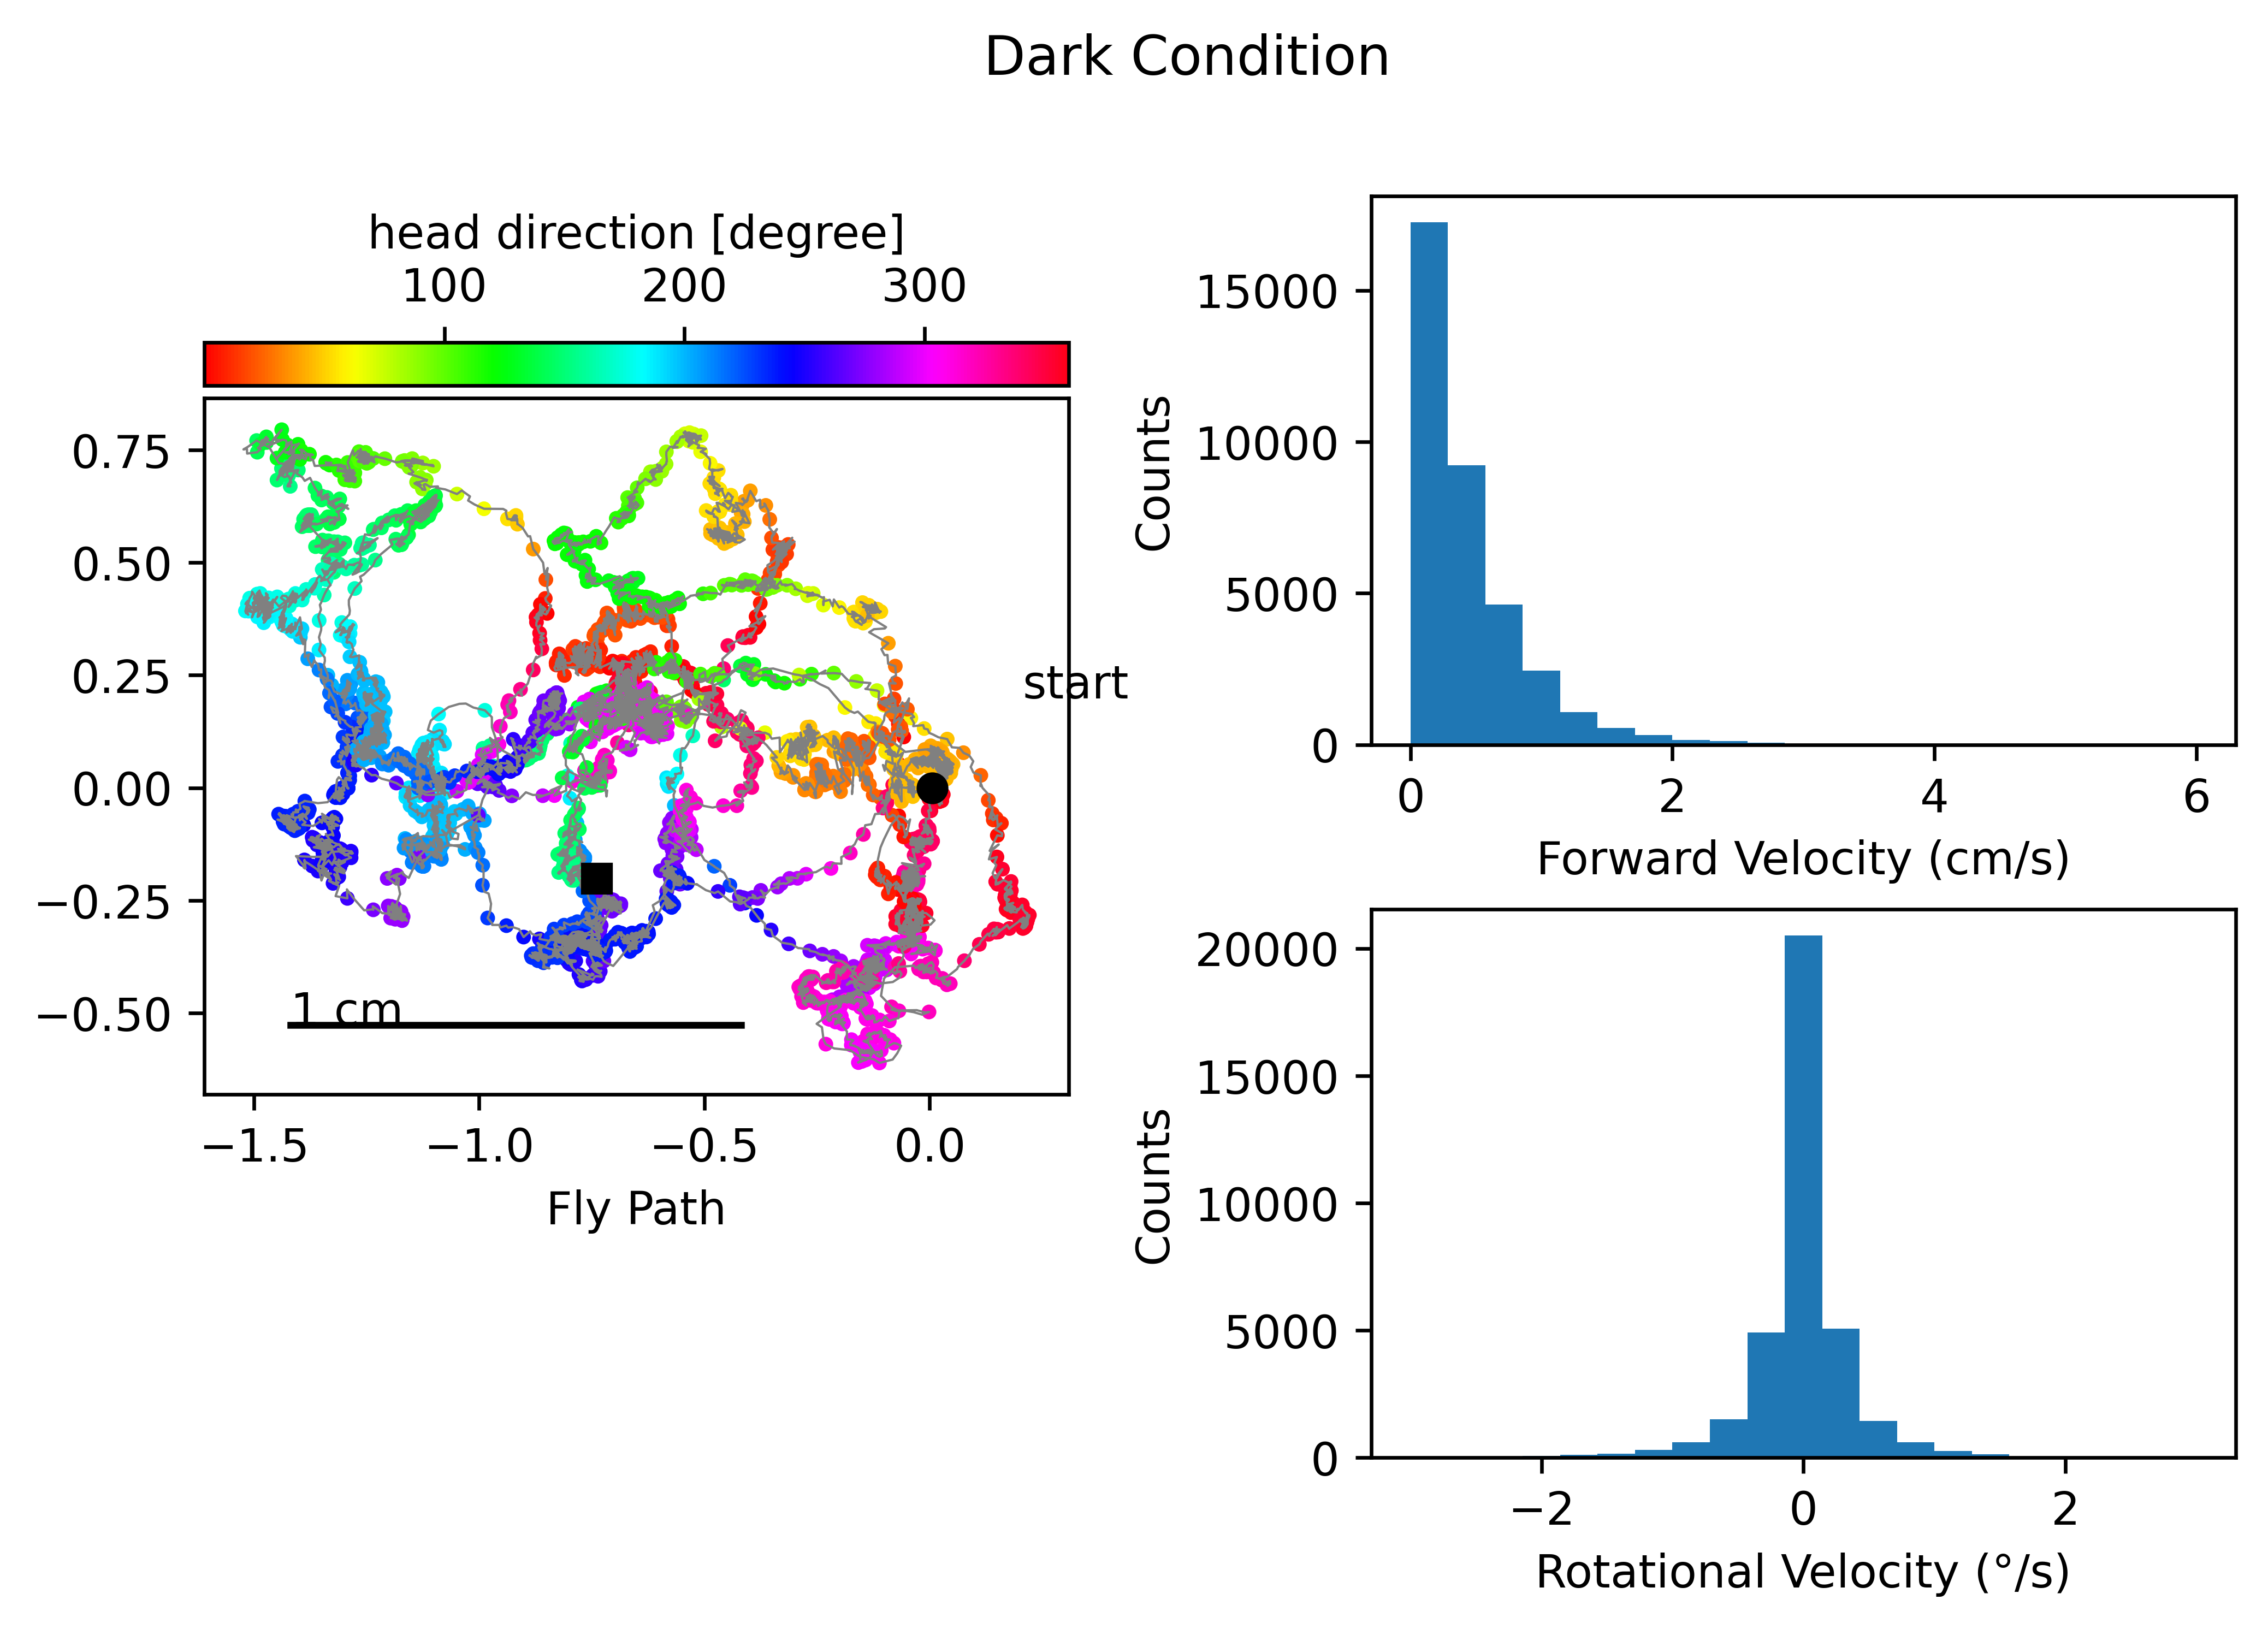

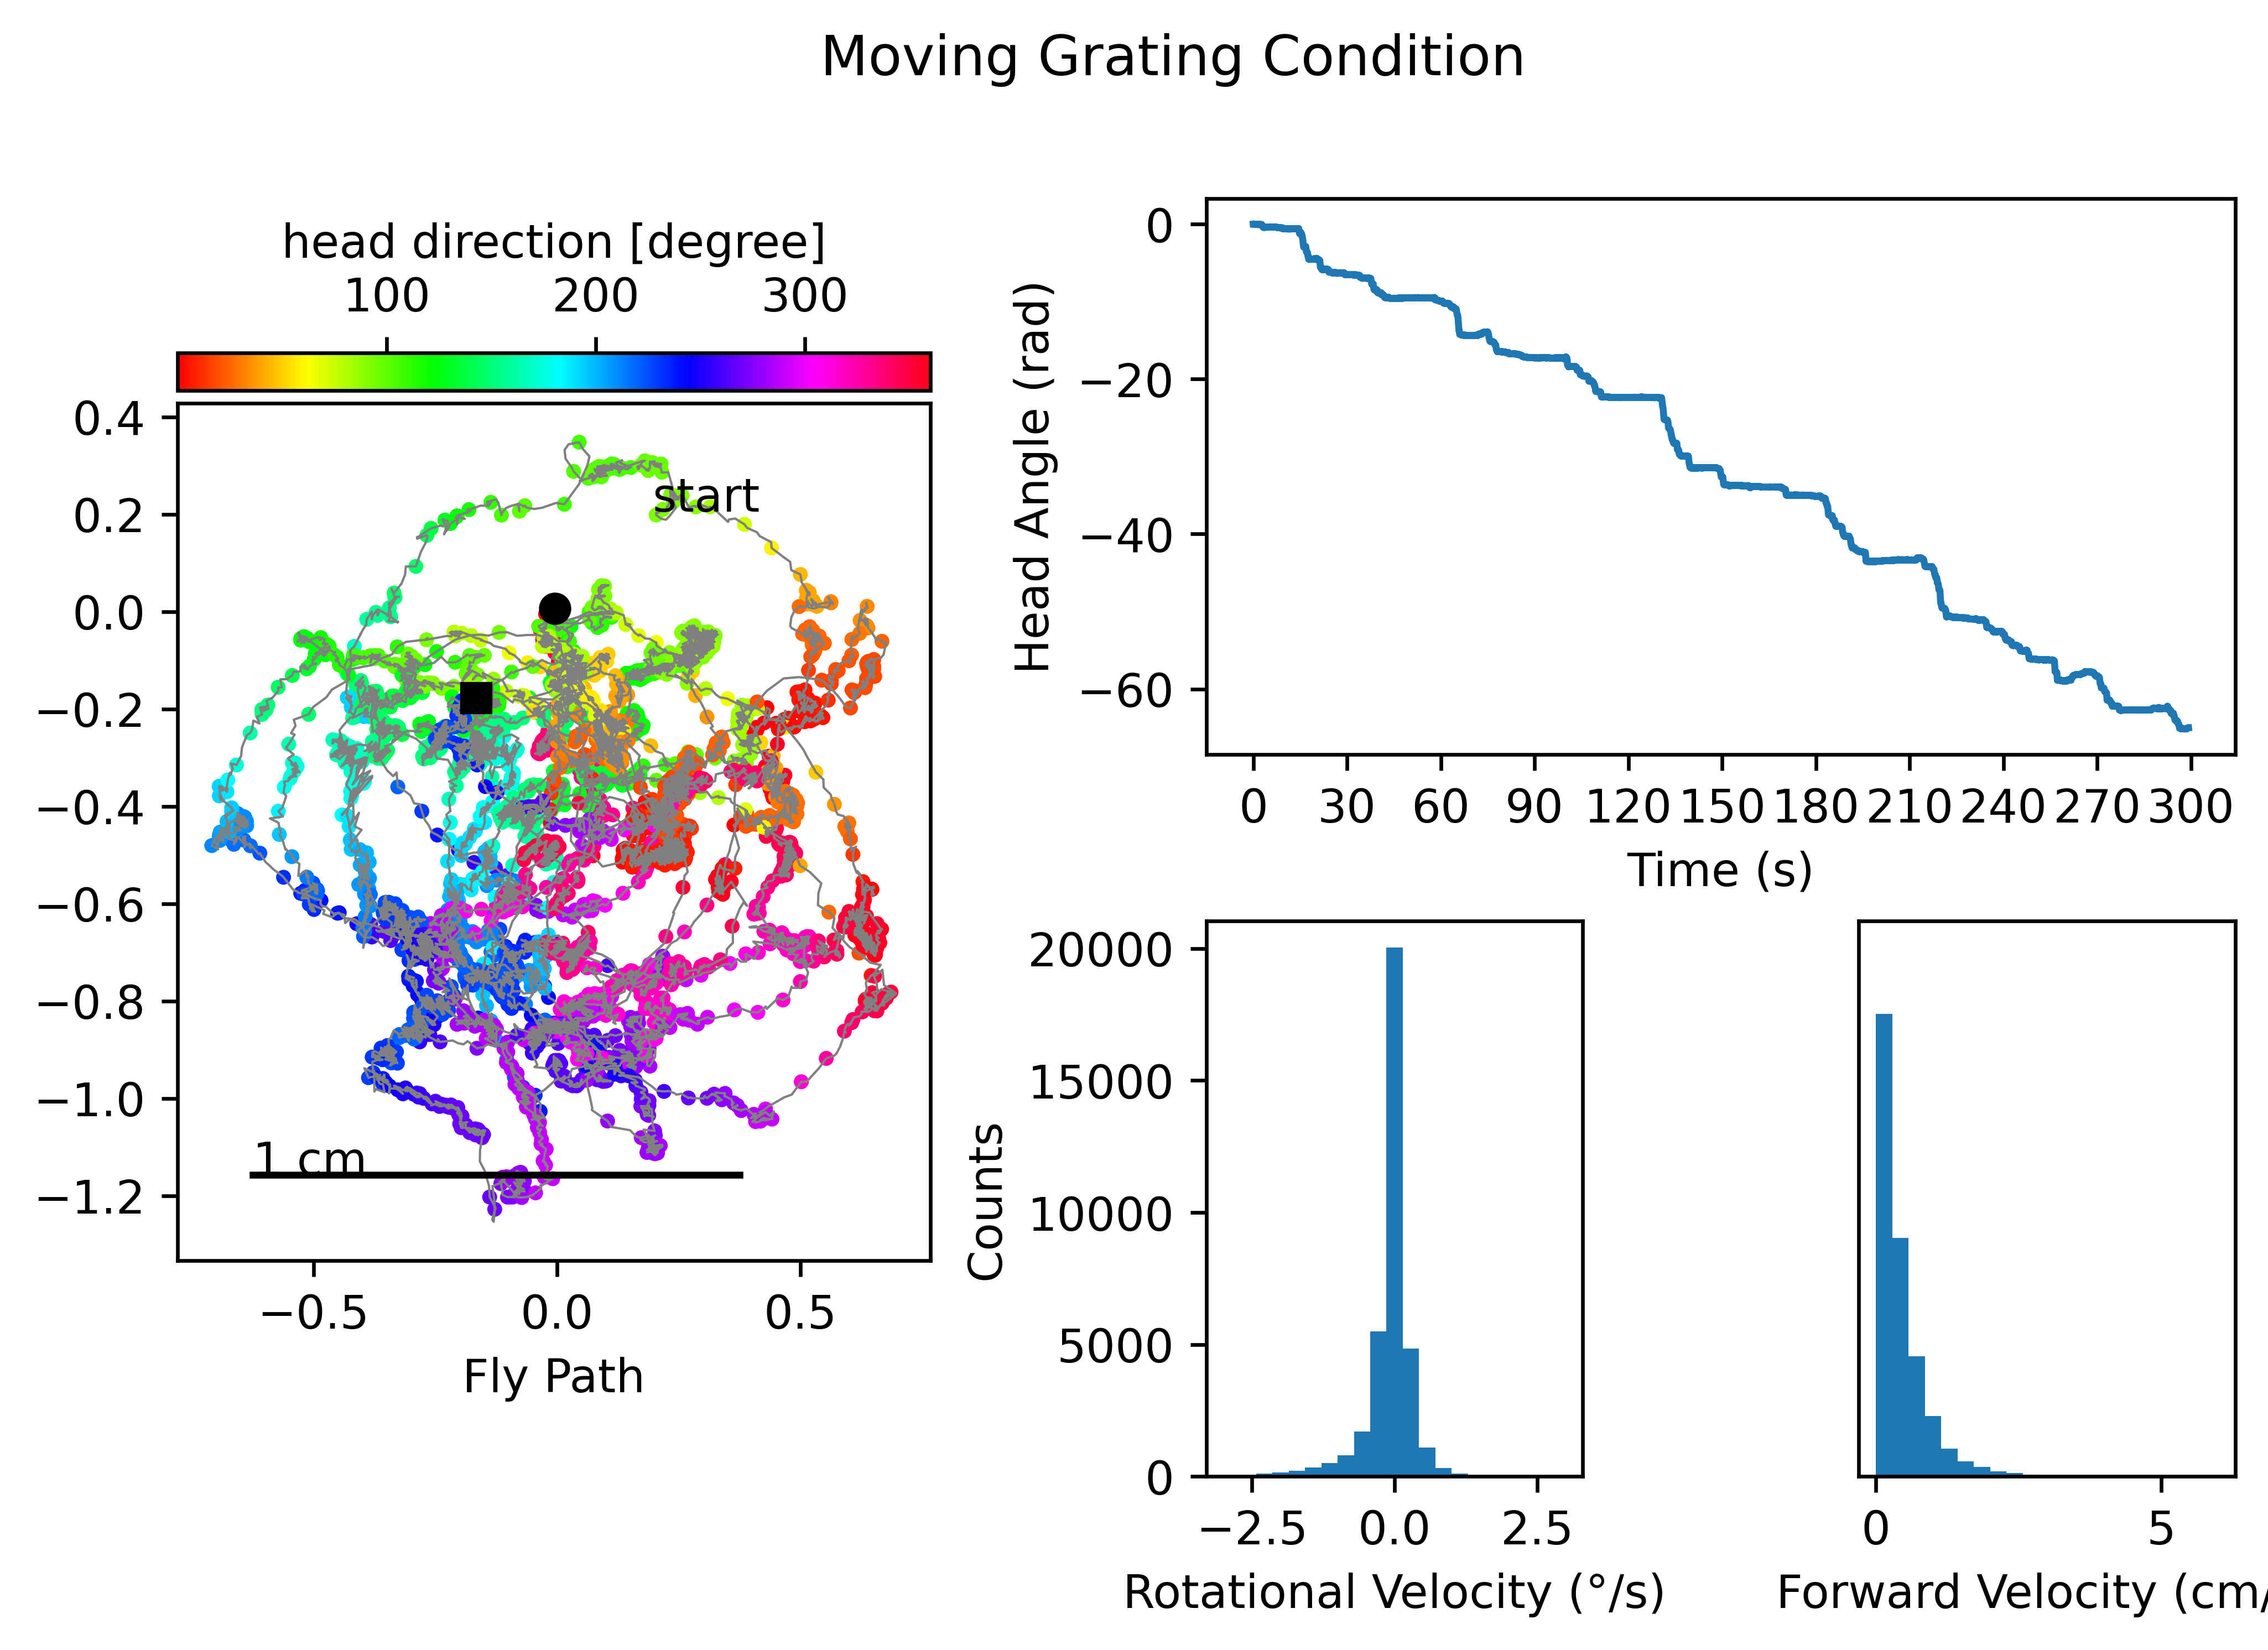

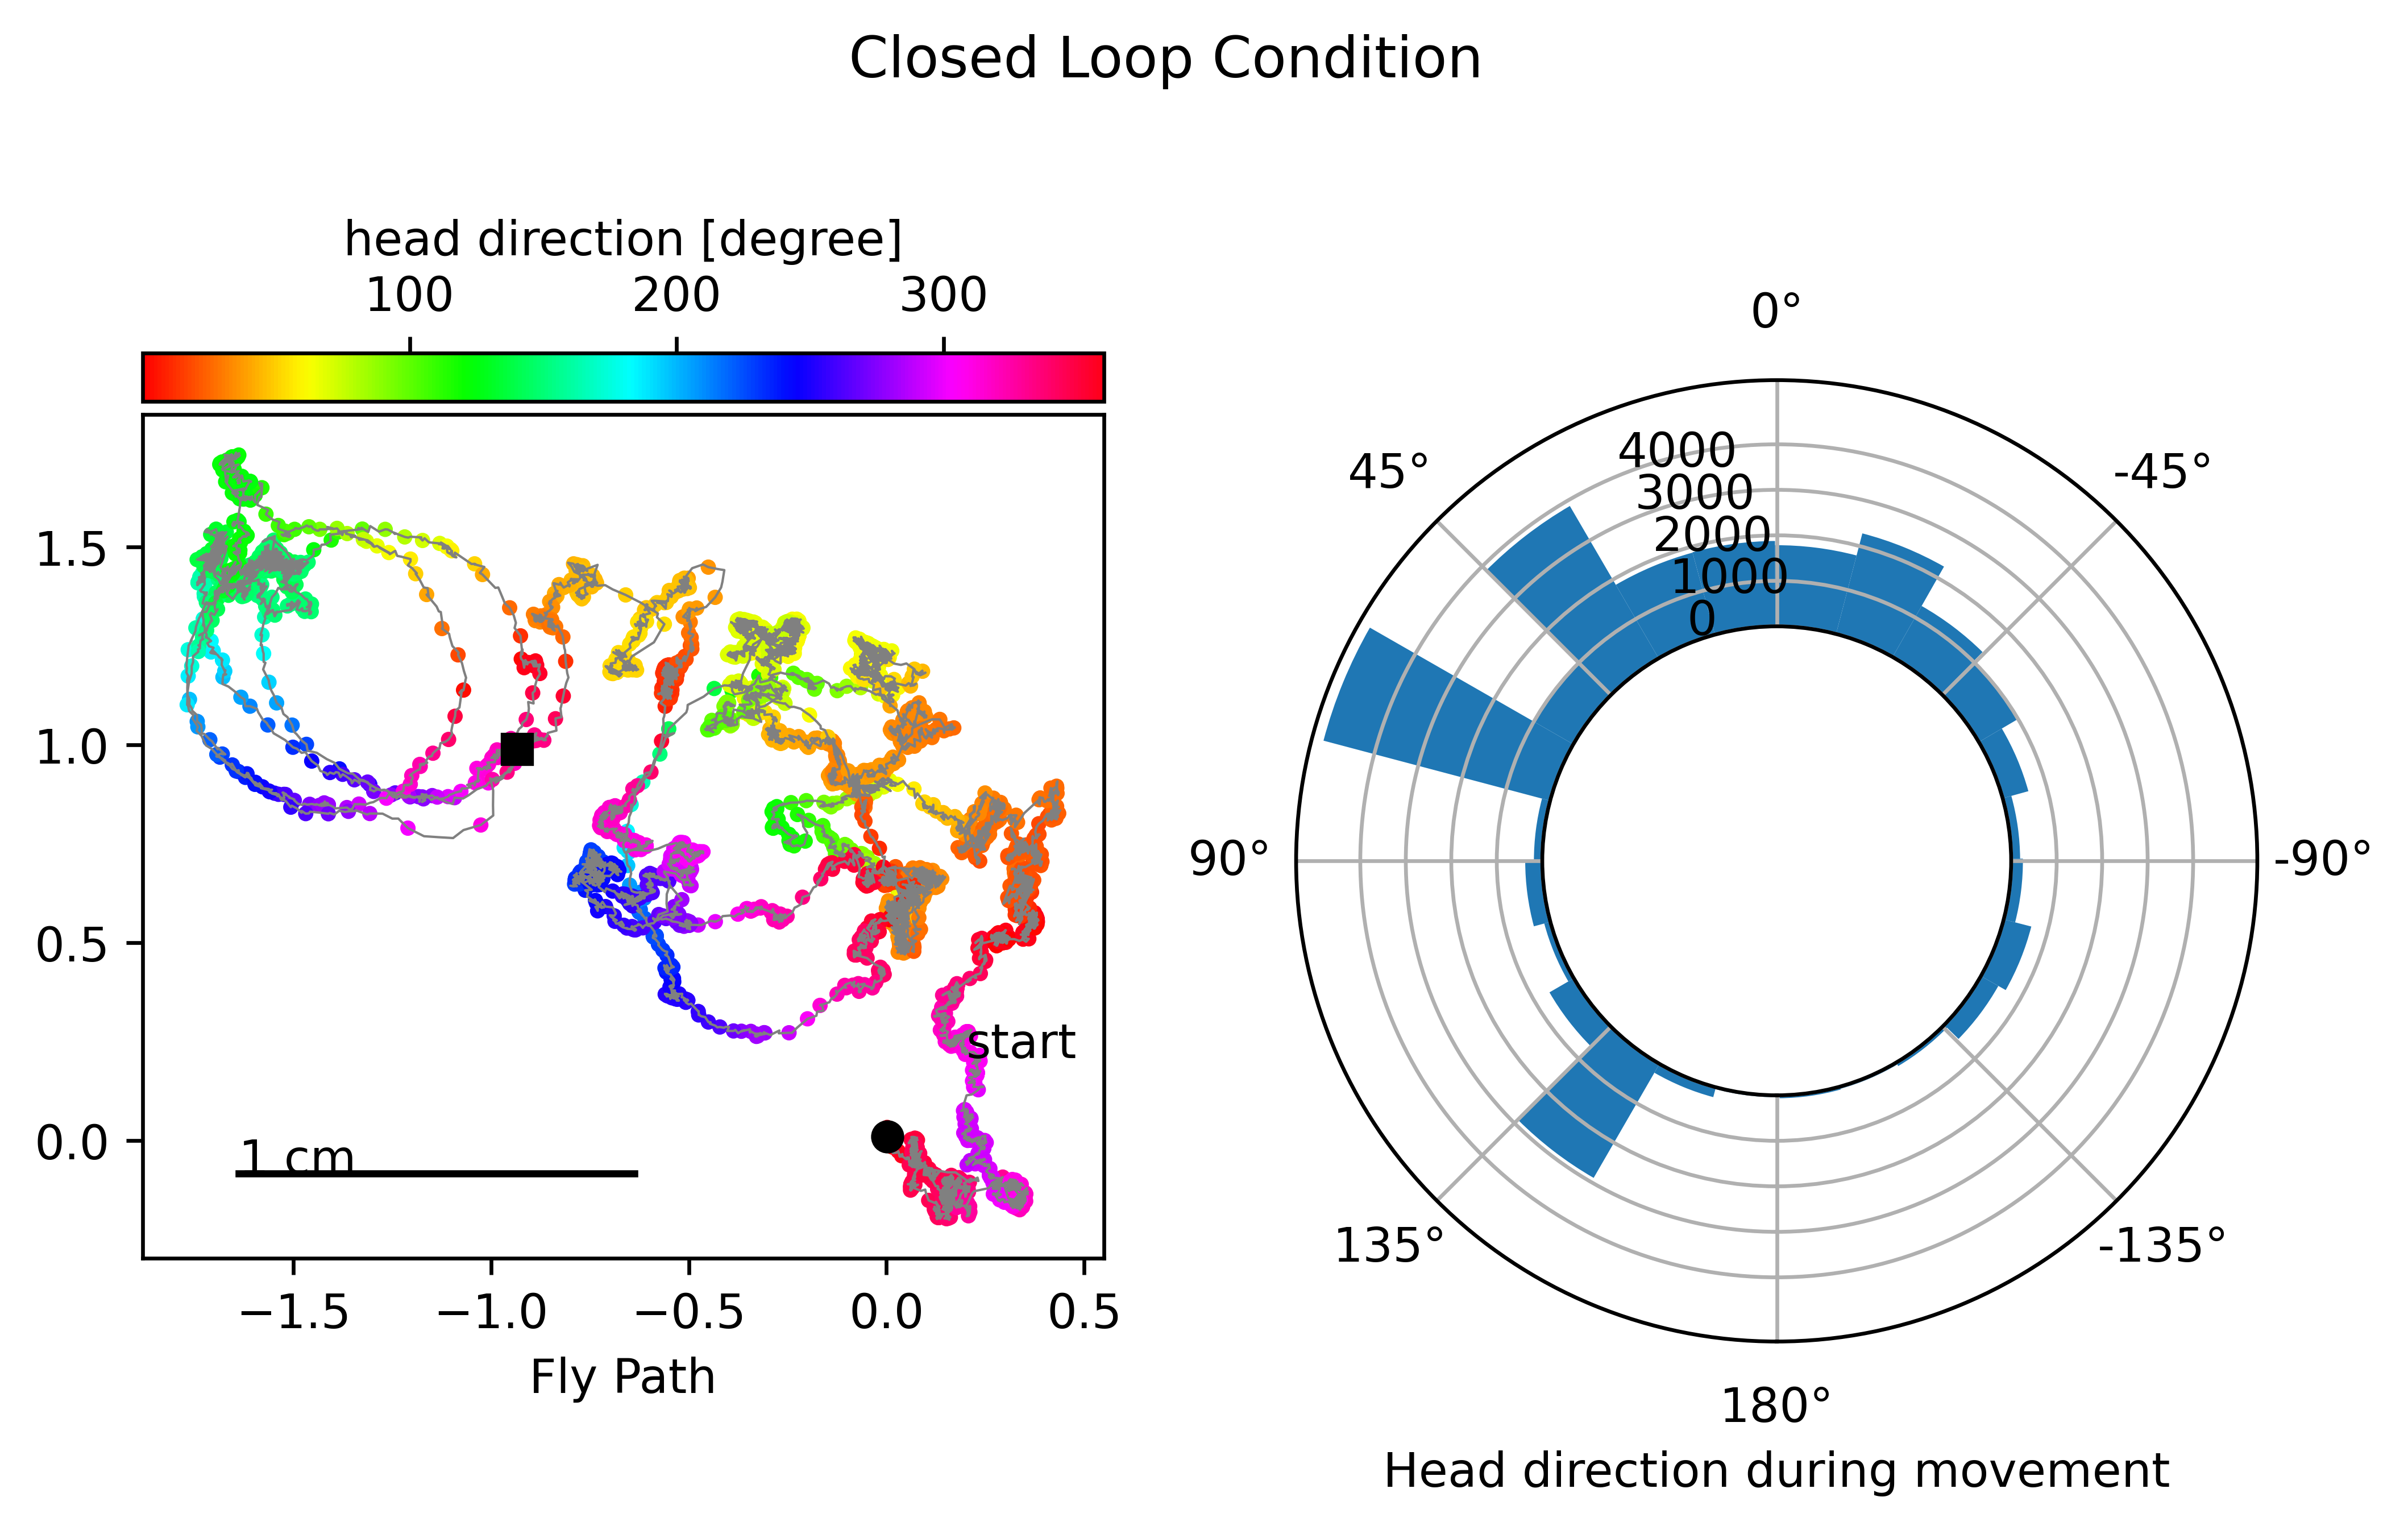

In [45]:
convfac = 10 # dc2cm

figsize = (8,5)

for index, (trial_type, uvr) in enumerate(uvr_dict.items()):
    fig = plt.figure(figsize=figsize)
    if trial_type == "dark_stim":
        plotting.plot_dark_stim(uvr, fig)
    if trial_type == "grating_stim":
        plotting.plot_grating_stim(uvr, fig)
    if trial_type == "closed_loop_stim":
        plotting.plot_closed_loop_stim(uvr, fig)
    file_name = f"{uvr.metadata['date']}_{uvr.metadata['time']}_{trial_type}"
    fig.savefig(Path(outfolder,file_name).with_suffix(".png"), dpi=600)
    fig.savefig(Path(outfolder,file_name).with_suffix(".svg"), dpi=600)

In [46]:
# dir_path_str = select_folder_str()
# filename = "trial_" + dark_stim_path.name.split('_')[1] + ".pdf"
# fig.savefig(Path(dir_path_str, filename), dpi=600)

## Check stimuli information

In [47]:
# uvr.posDf.describe()

In [48]:
# file_path = utils.select_file_path(prompt="Select UnityVR Trial")
# uvr = lp.constructUnityVRexperiment(str(file_path.parent), file_path.name)

In [49]:
# stimuliDf = uvr.stmDf
# print(stimuliDf.head())

# fig, axs = plt.subplots(2, gridspec_kw={'hspace': 0.75})

# axs[0].plot(stimuliDf['rotSpeed'])
# axs[0].set_yticks(stimuliDf.drop_duplicates(subset=['rotSpeed'])['rotSpeed'])
# axs[0].set_xlabel("frame")
# axs[0].set_ylabel("rotational speed (deg/sec)")
# axs[0].set_title("Stimuli Speed")

# axs[1].plot(stimuliDf['azimuth'])
# axs[1].set_yticks(range(0,360+1,90))
# axs[1].set_xlabel("frame")
# axs[1].set_ylabel("stimuli position (deg)")
# axs[1].set_title("Stimuli Position")


## Test Plotting Functions

In [50]:
# radangle_filt = uvr.posDf[uvr.posDf['vT_filt'] > uvr.posDf['vT_filt'].quantile(0.25)]['radangle']
# plt.hist([uvr.posDf.radangle, radangle_filt], bins=360//15, label=['raw', 'filt'])
# plt.legend()

## Create plot all on one figure with same information for all conditions (better comparability)
Plotting for each condition should include fly path, angle over time, forward and rotational histograms, and head direction histogram.
Also need to create a function to check if fictrac failed in a trial. (can identify based on unrealistic velocities (filtered))

In [51]:
def get_fictrac_error_periods(uvr):
    # Given a uvr trial return periods where fictrac lost tracking

    # Check if uvr object has computed velocities, if not compute them
    if not {'vT', 'vR'}.issubset(uvr.posDf.columns):
        posAnalysis.computeVelocities(uvr.posDf)

    # Get periods where filtered velocity went above large value (examine a trial with lost tracking)
    return uvr.posDf[uvr.posDf['vT_filt'] > 100]

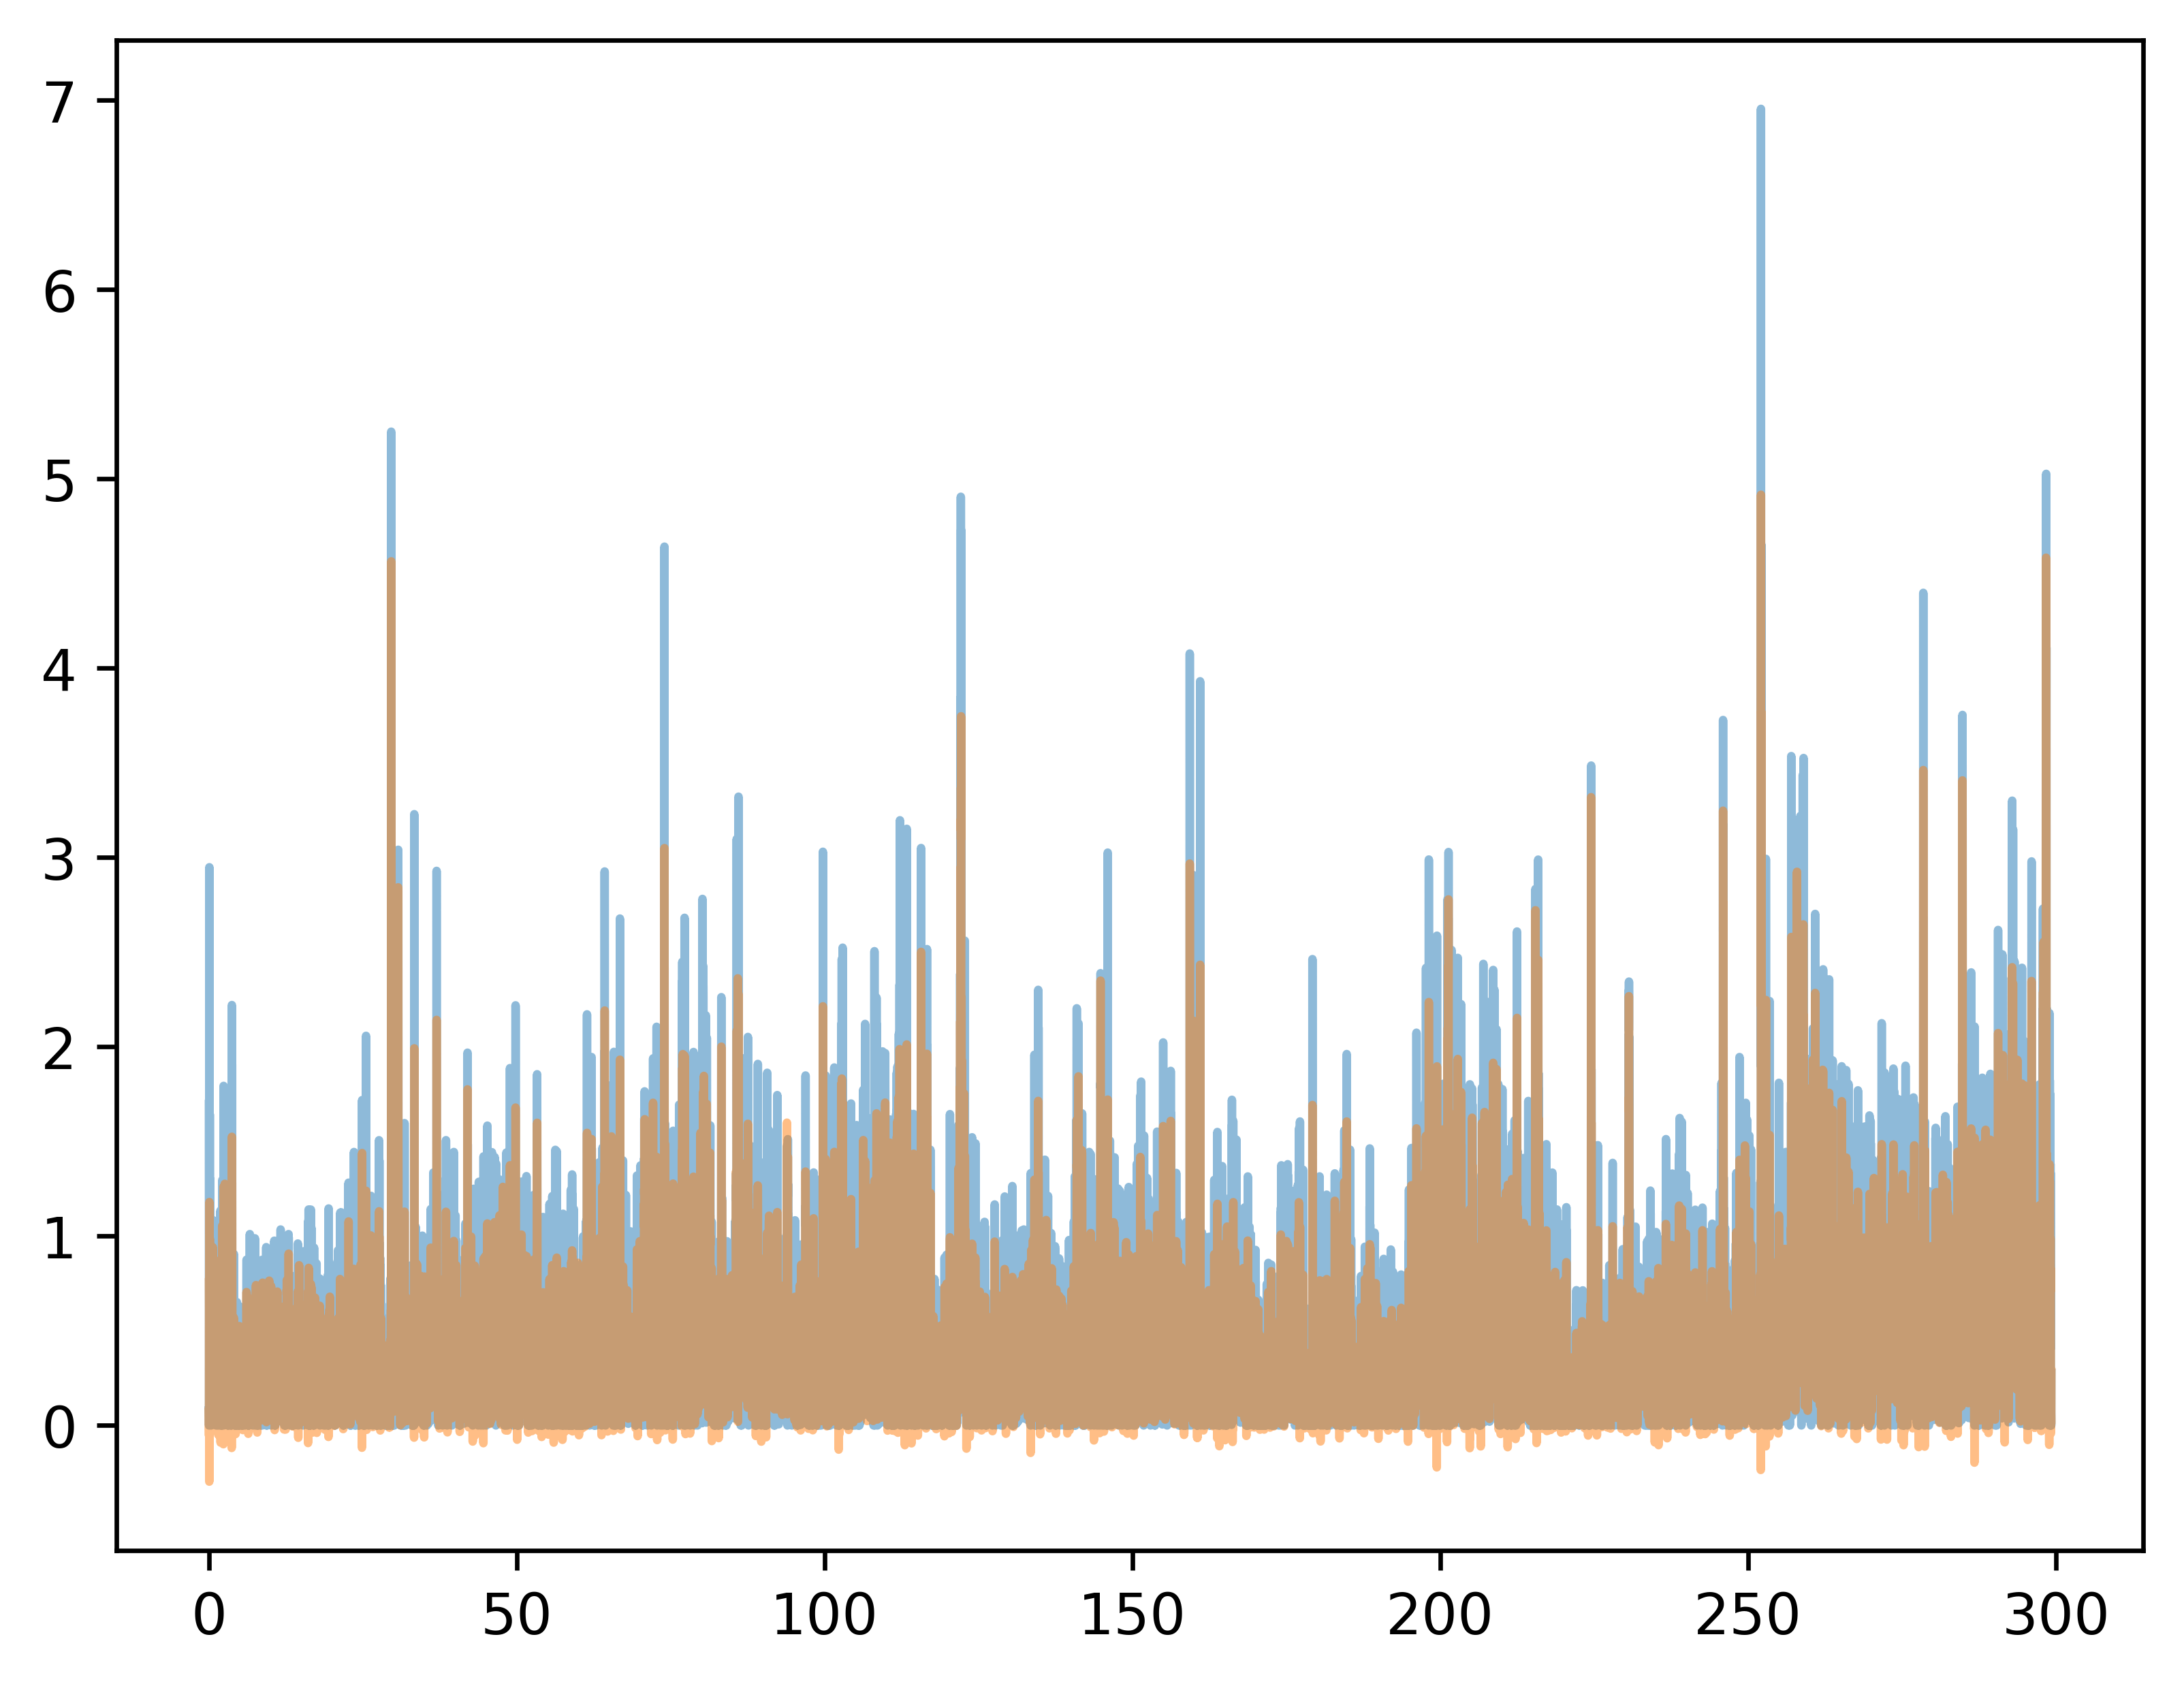

In [52]:
plt.plot(uvr_dict['closed_loop_stim'].posDf.time, uvr_dict['closed_loop_stim'].posDf.vT, alpha=0.5)
plt.plot(uvr_dict['closed_loop_stim'].posDf.time, uvr_dict['closed_loop_stim'].posDf.vT_filt, alpha=0.5)

In [53]:
get_fictrac_error_periods(uvr_dict['closed_loop_stim'])

,frame,time,dt,x,y,angle,dx,dy,dxattempt,dyattempt,ds,s,dTh,radangle,vT,vR,vT_filt,vR_filt


In [54]:
def plot_all_trial_data():
    # Given all three conditions from a trial,
    # Plot each condition with all types of information.
    
    pass